# Grid based A* planning

---- 

- conda env : [ai_robotics](../../README.md#setup-a-conda-environment)

---

### Ref
- https://github.com/AtsushiSakai/PythonRobotics/
- https://github.com/AtsushiSakai/PythonRobotics/blob/master/PathPlanning/AStar/a_star.py

---

- A* Variants Visualization Notebook
- Adapted from: Sarim Mehdi
- Refactored for FuncAnimation by ChatGPT (GPT-5)


### Imports and Configuration

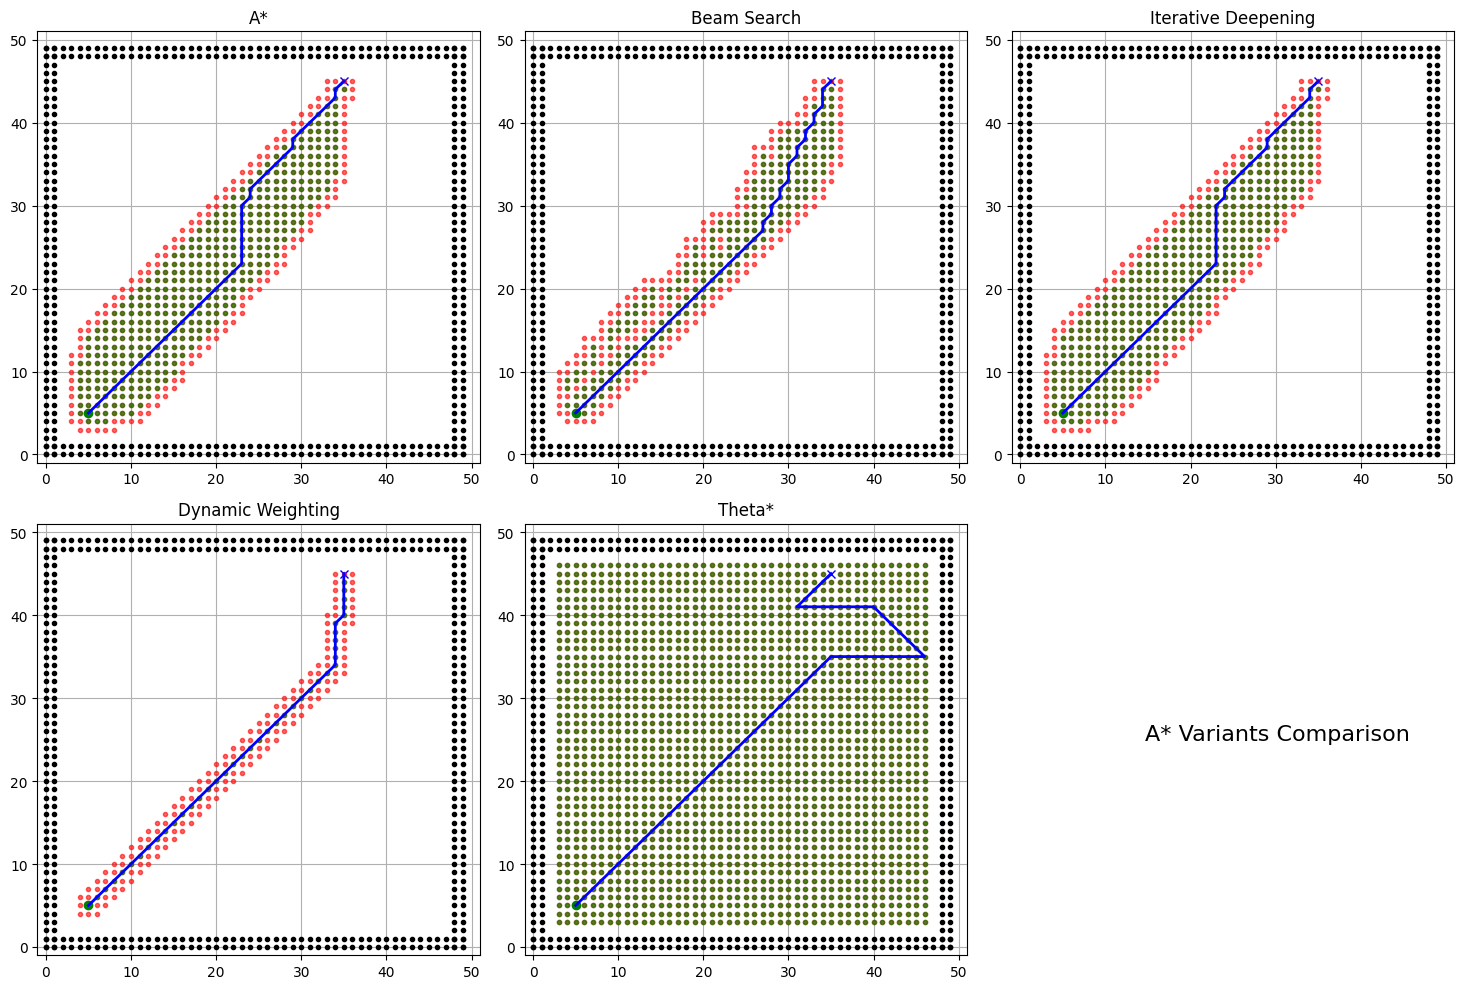

In [1]:
"""
A* Variants Comparison Visualization
Author: Adapted by ChatGPT (based on Sarim Mehdi)
Source: http://theory.stanford.edu/~amitp/GameProgramming/Variations.html
"""

import numpy as np
import matplotlib.pyplot as plt

# --- Constants ---
beam_capacity = 30
max_theta = 5
max_corner = 5
epsilon, upper_bound_depth = 4, 500

# --- Helper functions ---
def draw_horizontal_line(start_x, start_y, length, o_x, o_y, o_dict):
    for i in range(start_x, start_x + length):
        for j in range(start_y, start_y + 2):
            o_x.append(i)
            o_y.append(j)
            o_dict[(i, j)] = True

def draw_vertical_line(start_x, start_y, length, o_x, o_y, o_dict):
    for i in range(start_x, start_x + 2):
        for j in range(start_y, start_y + length):
            o_x.append(i)
            o_y.append(j)
            o_dict[(i, j)] = True

def in_line_of_sight(obs_grid, x1, y1, x2, y2):
    t = 0
    while t <= 0.5:
        xt = (1 - t) * x1 + t * x2
        yt = (1 - t) * y1 + t * y2
        if obs_grid.get((int(xt), int(yt)), True):
            return False, None
        t += 0.001
    dist = np.linalg.norm(np.array([x1, y1]) - np.array([x2, y2]))
    return True, dist

def key_points(o_dict):
    c_list = []
    for grid_point, obs_status in o_dict.items():
        if obs_status:
            continue
        x, y = grid_point
        has_obs = any(o_dict.get((x + i, y + j), True) for i in [-1, 0, 1] for j in [-1, 0, 1])
        if not has_obs:
            continue
        c_list.append((x, y))
    return c_list

# --- Search Algorithm ---
class SearchAlgo:
    def __init__(self, obs_grid, goal, start, limit, variant):
        self.start_pt = start
        self.goal_pt = goal
        self.obs_grid = obs_grid
        self.limit_x, self.limit_y = limit
        self.variant = variant
        self.all_nodes = {}
        self.open_set = []
        self.frames = []

        g_cost, h_cost = 0, self.hval(*start, *goal)
        f_cost = g_cost + h_cost

        for i in range(limit[0]):
            for j in range(limit[1]):
                self.all_nodes[(i, j)] = {'pos': [i, j], 'pred': None,
                                          'gcost': np.inf, 'hcost': self.hval(i, j, *goal),
                                          'fcost': np.inf, 'in_open_list': False, 'open': True}
        self.all_nodes[tuple(start)]['gcost'] = g_cost
        self.all_nodes[tuple(start)]['hcost'] = h_cost
        self.all_nodes[tuple(start)]['fcost'] = f_cost
        self.all_nodes[tuple(start)]['in_open_list'] = True
        self.open_set.append(self.all_nodes[tuple(start)])

    @staticmethod
    def hval(x1, y1, x2, y2):
        return np.hypot(x2 - x1, y2 - y1)

    def farthest_point(self, x, y, i, j):
        i_temp, j_temp = i, j
        counter = 1
        got_goal = False
        while not self.obs_grid.get((x + i_temp, y + j_temp), True) and counter < max_theta:
            i_temp += i
            j_temp += j
            counter += 1
            if [x + i_temp, y + j_temp] == self.goal_pt:
                got_goal = True
                break
        return i_temp - 2 * i, j_temp - 2 * j, counter, got_goal

    def run(self):
        goal_found = False
        curr_f_thresh = np.inf
        depth = 0

        while self.open_set:
            self.open_set.sort(key=lambda n: n['fcost'])
            current = self.open_set.pop(0)
            x1, y1 = current['pos']

            if [x1, y1] == self.goal_pt:
                goal_found = True
                break

            if self.variant == "beam" and len(self.open_set) > beam_capacity:
                self.open_set = self.open_set[:beam_capacity]

            f_cost_list = []

            for i in range(-1, 2):
                for j in range(-1, 2):
                    if i == 0 and j == 0:
                        continue
                    cand_x, cand_y = x1 + i, y1 + j
                    if (cand_x, cand_y) not in self.obs_grid or self.obs_grid[(cand_x, cand_y)]:
                        continue
                    offset = np.hypot(i, j)

                    # Theta* look-ahead
                    if self.variant == "theta":
                        di, dj, steps, goal_hit = self.farthest_point(x1, y1, i, j)
                        cand_x, cand_y = x1 + di, y1 + dj
                        offset *= steps
                        if goal_hit:
                            self.all_nodes[tuple(self.goal_pt)]['pred'] = current['pos']
                            goal_found = True
                            break

                    g_cost = current['gcost'] + offset
                    h_cost = self.hval(cand_x, cand_y, *self.goal_pt)
                    if self.variant == "dynamic":
                        w = (1 + epsilon - epsilon * depth / upper_bound_depth)
                        h_cost *= w
                    f_cost = g_cost + h_cost
                    cand_pt = (cand_x, cand_y)

                    if f_cost < self.all_nodes[cand_pt]['fcost']:
                        self.all_nodes[cand_pt].update({
                            'pred': current['pos'],
                            'gcost': g_cost,
                            'hcost': h_cost,
                            'fcost': f_cost
                        })
                        if not self.all_nodes[cand_pt]['in_open_list']:
                            self.open_set.append(self.all_nodes[cand_pt])
                            self.all_nodes[cand_pt]['in_open_list'] = True
                            self.frames.append(('open', cand_pt))
                    f_cost_list.append(f_cost)

            self.frames.append(('closed', (x1, y1)))
            depth += 1
            if self.variant == "iterative":
                if f_cost_list:
                    curr_f_thresh = min(f_cost_list)

        # Trace path
        path_pts = []
        if goal_found:
            node = self.all_nodes[tuple(self.goal_pt)]
            while node['pred']:
                path_pts.append(tuple(node['pos']))
                node = self.all_nodes[tuple(node['pred'])]
            path_pts.append(tuple(self.start_pt))
        return self.frames, path_pts

# --- Setup environment ---
def setup_env():
    obs_dict = {(i, j): False for i in range(51) for j in range(51)}
    o_x, o_y = [], []
    draw_vertical_line(0, 0, 50, o_x, o_y, obs_dict)
    draw_vertical_line(48, 0, 50, o_x, o_y, obs_dict)
    draw_horizontal_line(0, 0, 50, o_x, o_y, obs_dict)
    draw_horizontal_line(0, 48, 50, o_x, o_y, obs_dict)
    return obs_dict, o_x, o_y

# --- Run all approaches ---
variants = {
    "A*": "astar",
    "Beam Search": "beam",
    "Iterative Deepening": "iterative",
    "Dynamic Weighting": "dynamic",
    "Theta*": "theta"
}

obs_dict, o_x, o_y = setup_env()
s_x, s_y, g_x, g_y = 5, 5, 35, 45

results = {}
for label, var in variants.items():
    algo = SearchAlgo(obs_dict, [g_x, g_y], [s_x, s_y], (51, 51), var)
    frames, path = algo.run()
    results[label] = (frames, path)

# --- Render results side-by-side ---
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (label, (frames, path)) in enumerate(results.items()):
    ax = axes[idx]
    ax.plot(o_x, o_y, ".k")
    ax.plot(s_x, s_y, "og")
    ax.plot(g_x, g_y, "xb")
    ax.set_xlim(-1, 51)
    ax.set_ylim(-1, 51)
    ax.set_title(label)
    ax.grid(True)
    open_pts = [pt for a, pt in frames if a == 'open']
    closed_pts = [pt for a, pt in frames if a == 'closed']
    if open_pts:
        ax.plot(*zip(*open_pts), "r.", alpha=0.6)
    if closed_pts:
        ax.plot(*zip(*closed_pts), "g.", alpha=0.6)
    if path:
        ax.plot(*zip(*path), "b-", linewidth=2)

axes[-1].axis('off')
axes[-1].text(0.3, 0.5, "A* Variants Comparison", fontsize=16)
plt.tight_layout()
plt.show()
